In [1]:
import numpy as np
from numpy import ndarray
from typing import Callable, Dict, Tuple, List

In [2]:
np.set_printoptions(precision=4)
TEST_ALL = False

Data Importation and Loading

In [3]:
'''
from sklearn.datasets import load_boston
boston = load_boston
data = boston.data
target = boston.target
features = boston.feature_names
'''
# Boston housing data has been deprecated because of ethical issues, but I am using it for learning purpose only
import pandas as pd
pd.set_option('display.width', 1000)

features = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Data visualization using DF
'''
df = pd.DataFrame(data, columns=features)
df['TARGET'] = target
print(df.head())
'''


"\ndf = pd.DataFrame(data, columns=features)\ndf['TARGET'] = target\nprint(df.head())\n"

Data Prep

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
s = StandardScaler()
data = s.fit_transform(data)
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=80718)
y_train, y_test = y_train.reshape(-1,1), y_test.reshape(-1,1)

In [30]:
def mse(actual: ndarray, prediction: ndarray):
  # Mean Squared Error Computation
  return np.mean(np.square(actual-prediction))

def mae(actual: ndarray, prediction: ndarray):
  # Mean Absolute Error Computation
  return np.mean(np.abs(actual-prediction))

def rmse(actual: ndarray, prediction: ndarray):
  # Root Mean Square Error
  return np.sqrt(mse(actual, prediction))

In [5]:
def forward_pass(x_batch: ndarray,
                 y_batch: ndarray,
                 weights: Dict[str, ndarray]
                 ) -> Tuple[float, Dict[str, ndarray]]:

    # Forward pass algorithm for the step-by-step linear regression model

    w_batch: ndarray = weights['W']
    b_batch: ndarray = weights['B']

    # Assert that batch sizes of X and Y matrices are equal.
    # This is to ensure that all observations for training have targets.
    # That there are no missing targets.
    assert x_batch.shape[0] == y_batch.shape[0]

    #Assert that matrice multiplication can work. i.e n of x_batch == m of weights['W']
    assert x_batch.shape[1] == w_batch.shape[0]

    # Assert that B, the intersection on the dependent axis is a 1x1 array
    assert b_batch.shape[0] == b_batch.shape[1]

    # Compute the operations on the forward pass
    n: ndarray = np.dot(x_batch, w_batch)
    p: ndarray = n + b_batch

    # Finding the residuals - the loss
    loss: float = np.mean(np.square(y_batch - p))

    # Save the results from the forward pass operation
    forward_pass_result: Dict[str, ndarray] = {}
    forward_pass_result['X'] = x_batch
    forward_pass_result['N'] = n
    forward_pass_result['P'] = p
    forward_pass_result['Y'] = y_batch

    return loss, forward_pass_result


In [6]:
def loss_gradient(forward_pass_result: Dict[str, ndarray],
                  weights: Dict[str, ndarray]) -> Dict[str, ndarray]:
    # Calculating by what factor the inputs have to change for the loss value to reduce
    dLdP = -2 * (forward_pass_result['Y']-forward_pass_result['P'])
    dPdN = np.ones_like(forward_pass_result['N'])
    dPdB = np.ones_like(weights['B'])

    dLdN = dLdP * dPdN
    dLdB = (dLdP * dPdB).sum(axis=0)

    dNdW = np.transpose(forward_pass_result['X'], (1,0))
    dLdW = np.dot(dNdW, dLdN)

    # Declaring return object
    loss_gradient_result: Dict[str, ndarray] = {}
    loss_gradient_result['W'] = dLdW
    loss_gradient_result['B'] = dLdB

    return loss_gradient_result

In [7]:
def to_2d_np(a: ndarray, type="col")-> ndarray:
    # TURNS A 1D ARRAY INTO A 2D ARRAY

    assert a.ndim == 1

    if type == "col":
        return a.reshape(-1,1)
    elif type == "row":
        return a.reshape(1,-1)
    else:
        raise ValueError('type must be "col" or "row"')


In [8]:
def permute_data(x: ndarray, y: ndarray):
    # Shuffles matrix x and y stochastically

    perm = np.random.permutation(x.shape[0])
    #print("Permuted Data::\n", perm)
    #print("Permuted X Data::\n", x[perm])
    #print("Permuted Y Data::\n", y[perm])
    return x[perm], y[perm]

In [9]:
Batch = Tuple[ndarray, ndarray]

def generate_batch(x: ndarray,
                   y: ndarray,
                   start: int = 0,
                   batch_size: int = 10) -> Batch:
    # Generates batch from x and y matrices, given a start position and batch size

    # x and y must be 2-dimensional
    assert x.ndim == y.ndim == 2

    if start + batch_size > x.shape[0]:
        batch_size = x.shape[0] - start

    x_batch, y_batch = x[start:start + batch_size], y[start:start + batch_size]

    return x_batch, y_batch

In [10]:
def init_weights(n_in: int) -> Dict[str, ndarray]:
    # Initializes weight on first forward pass model
    weights: Dict[str, ndarray] = {}
    W = np.random.randn(n_in, 1)
    B = np.random.randn(1, 1)
    weights['W'] = W
    weights['B'] = B

    return weights

In [11]:
def train(x: ndarray,
          y: ndarray,
          n_iter: int = 1000,
          learning_rate: float = 0.1,
          batch_size: int = 100,
          return_losses: bool = False,
          return_weights: bool = False,
          seed: int = 1) ->  None:
    # Train model for a certain number of epochs

    if seed:
        np.random.seed(seed)
    start = 0

    # Initialize weights
    weights = init_weights(x.shape[1])
    print("Weights:\n", weights)

    # Permute data
    x, y = permute_data(x, y)

    losses = []

    for i in range(n_iter):
        # Generate batch
        if start >= x.shape[0]:
            x, y = permute_data(x, y)
            start = 0

        x_batch, y_batch = generate_batch(x, y, start, batch_size)
        start += batch_size

        # Train using generated batch
        loss, forward_info = forward_pass(x_batch, y_batch, weights)

        #print("Loss::\n", loss, "Forward Info::\n", forward_info)

        if return_losses:
          losses.append(loss)

        backward_pass = loss_gradient(forward_info, weights)

        #print("Backward Pass::\n", backward_pass)

        for key in backward_pass.keys():
            weights[key] -= learning_rate * backward_pass[key]

    if return_weights:
        return losses, weights

    return None

In [12]:
train_result = train(x_train,
                     y_train,
                     n_iter=1000,
                     learning_rate=0.0001,
                     batch_size=23,
                     return_losses=True,
                     return_weights=True,
                     seed=180708)

print("Train result::\n", train_result)
losses, weights = train_result[0], train_result[1]

Weights:
 {'W': array([[ 0.9279],
       [-0.1065],
       [ 1.7624],
       [-0.2992],
       [ 0.7883],
       [-0.2741],
       [-0.132 ],
       [ 0.0033],
       [-0.5417],
       [ 1.1061],
       [ 0.3206],
       [ 1.701 ],
       [ 0.8567]]), 'B': array([[-0.2155]])}
Train result::
 ([np.float64(813.2098258057699), np.float64(826.5811488324706), np.float64(523.0168165606822), np.float64(627.9966475912304), np.float64(678.913833108105), np.float64(568.5590903533431), np.float64(637.3168411927973), np.float64(549.9555907455891), np.float64(552.6630670369867), np.float64(639.4932970143942), np.float64(425.14769265506646), np.float64(662.2846656226723), np.float64(613.8829345446594), np.float64(475.97774382153233), np.float64(443.1938332195952), np.float64(759.1659569023444), np.float64(460.2494445342717), np.float64(539.3043774071501), np.float64(504.82555663861666), np.float64(475.0568452211231), np.float64(447.7918167886699), np.float64(544.6226202941787), np.float64(443.441662

Text(0.5, 1.0, 'A Graph of Loss vs Epochs')

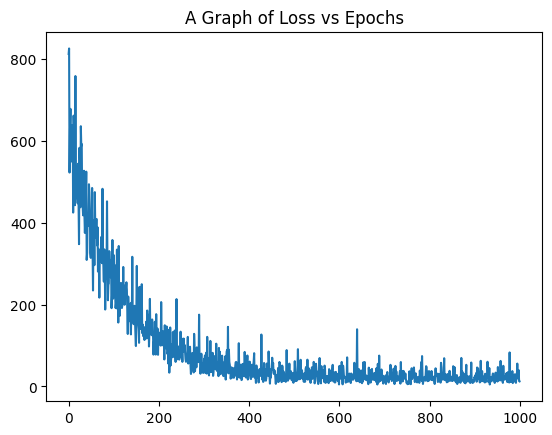

In [13]:
import matplotlib.pyplot as plt
plt.plot(list(range(1000)), train_result[0])
plt.title("A Graph of Loss vs Epochs")

In [24]:
def predict(x: ndarray, weights: ndarray) -> ndarray:
  # Predict house prices using the manually trained model
  N = np.dot(x, weights['W'])
  return np.add(N, weights['B'])

In [25]:
predictions = predict(x_test, weights)
print(np.round(predictions, 4))

[[37.693 ]
 [16.3632]
 [19.7945]
 [ 4.9387]
 [22.7105]
 [21.4589]
 [18.474 ]
 [23.657 ]
 [31.327 ]
 [ 9.976 ]
 [32.3281]
 [17.3947]
 [15.8989]
 [35.9575]
 [16.7033]
 [24.6353]
 [17.996 ]
 [23.5676]
 [25.4947]
 [25.5393]
 [22.6707]
 [22.7687]
 [13.8236]
 [25.2202]
 [14.4458]
 [27.1319]
 [27.6173]
 [33.8444]
 [34.2211]
 [20.5887]
 [ 5.3383]
 [13.0194]
 [26.4998]
 [21.3928]
 [21.582 ]
 [38.2849]
 [36.2539]
 [24.9362]
 [26.9068]
 [27.5057]
 [34.3036]
 [23.5793]
 [34.6915]
 [16.8041]
 [28.2021]
 [28.6325]
 [20.7474]
 [20.2005]
 [ 7.6068]
 [23.5864]
 [20.4406]
 [12.302 ]
 [22.0009]
 [23.2573]
 [26.3348]
 [34.8079]
 [23.845 ]
 [23.5883]
 [20.7008]
 [20.2872]
 [23.8274]
 [30.4197]
 [12.8903]
 [31.0564]
 [19.9457]
 [29.0362]
 [27.5544]
 [15.6429]
 [13.4655]
 [15.7257]
 [14.4054]
 [18.7476]
 [14.0185]
 [12.5792]
 [17.3848]
 [23.0616]
 [10.6861]
 [18.6501]
 [23.6449]
 [21.2828]
 [19.8286]
 [24.4714]
 [22.6746]
 [20.3517]
 [24.0107]
 [-4.5317]
 [25.0276]
 [17.557 ]
 [20.5109]
 [ 5.6106]
 [24.0583]

In [33]:
print("MSE::", mse(y_test, predictions))
print("MAE::", mae(y_test, predictions))
print("RMSE::", rmse(y_test, predictions))

MSE:: 26.46512947826173
MAE:: 3.5206468441482546
RMSE:: 5.144427031095079


In [34]:
from sklearn.linear_model import LinearRegression
np.round(lr.coef_, 2)

NameError: name 'lr' is not defined